# Inverse QFT Tests

# Project 7b: The Inverse Quantum Fourier Transform (IQFT)

**Objective:** Build an Inverse QFT circuit to decode phase rotations back into classical computational basis states.

**Theory:**
Because quantum gates are perfectly reversible (unitary), any algorithm we run forward can be run backward. To build the Inverse QFT, we must apply the exact same operations as the QFT, but in the **reverse order**, and with **negative phase angles**. 

If we encode the number `5` into the phase basis using our QFT, and then immediately apply our IQFT, the phase rotations will perfectly un-wind. The superposition will collapse, and we will measure the binary string `101` with 100% certainty.

In [1]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from IPython.display import display
import numpy as np

print("Environment Ready.")

Environment Ready.


In [2]:
def build_qft(n: int) -> QuantumCircuit:
    """The Forward QFT from our previous experiment."""
    qc = QuantumCircuit(n, name="QFT")
    for i in range(n - 1, -1, -1):
        qc.h(i)
        for j in range(i - 1, -1, -1):
            qc.cp(np.pi / (2 ** (i - j)), j, i)
    for i in range(n // 2):
        qc.swap(i, n - 1 - i)
    return qc

## Step 1: Building the IQFT Generator

To reverse the forward QFT:
1. We apply the `SWAP` gates *first*.
2. We loop forward through the qubits (instead of backward).
3. We apply the negative Controlled-Phase (`-cp`) rotations *before* applying the Hadamard (`H`) gates.

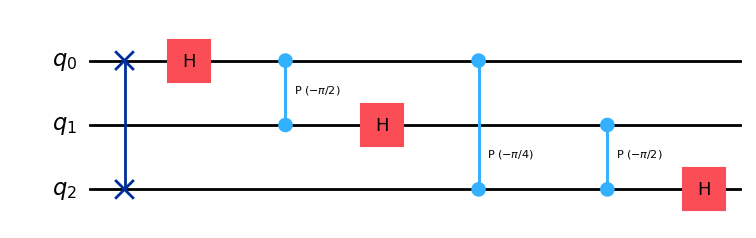

In [3]:
def build_iqft(n: int) -> QuantumCircuit:
    """Constructs the Inverse Quantum Fourier Transform."""
    qc = QuantumCircuit(n, name="IQFT")
    
    # 1. Reverse the SWAP gates
    for i in range(n // 2):
        qc.swap(i, n - 1 - i)
        
    # 2. Iterate forward through the qubits
    for i in range(n):
        # Apply the inverse controlled-phase rotations
        for j in range(i):
            qc.cp(-np.pi / (2 ** (i - j)), j, i)
        
        # Apply the Hadamard gate last
        qc.h(i)
        
    return qc

# Visualize the 3-qubit IQFT
display(build_iqft(3).draw('mpl'))

## Step 2: The Round-Trip Test

We will now perform the full lifecycle of Fourier encoding:
1.  **Classical Initialization:** Set the qubits to `101` (Number 5).
2.  **Encode:** Apply the `QFT` to push the number into the phase basis.
3.  **Decode:** Apply the `IQFT` to pull the phases back to the classical basis.
4.  **Measurement:** Ensure we get `101` out of the system.

Full QFT -> IQFT Circuit:


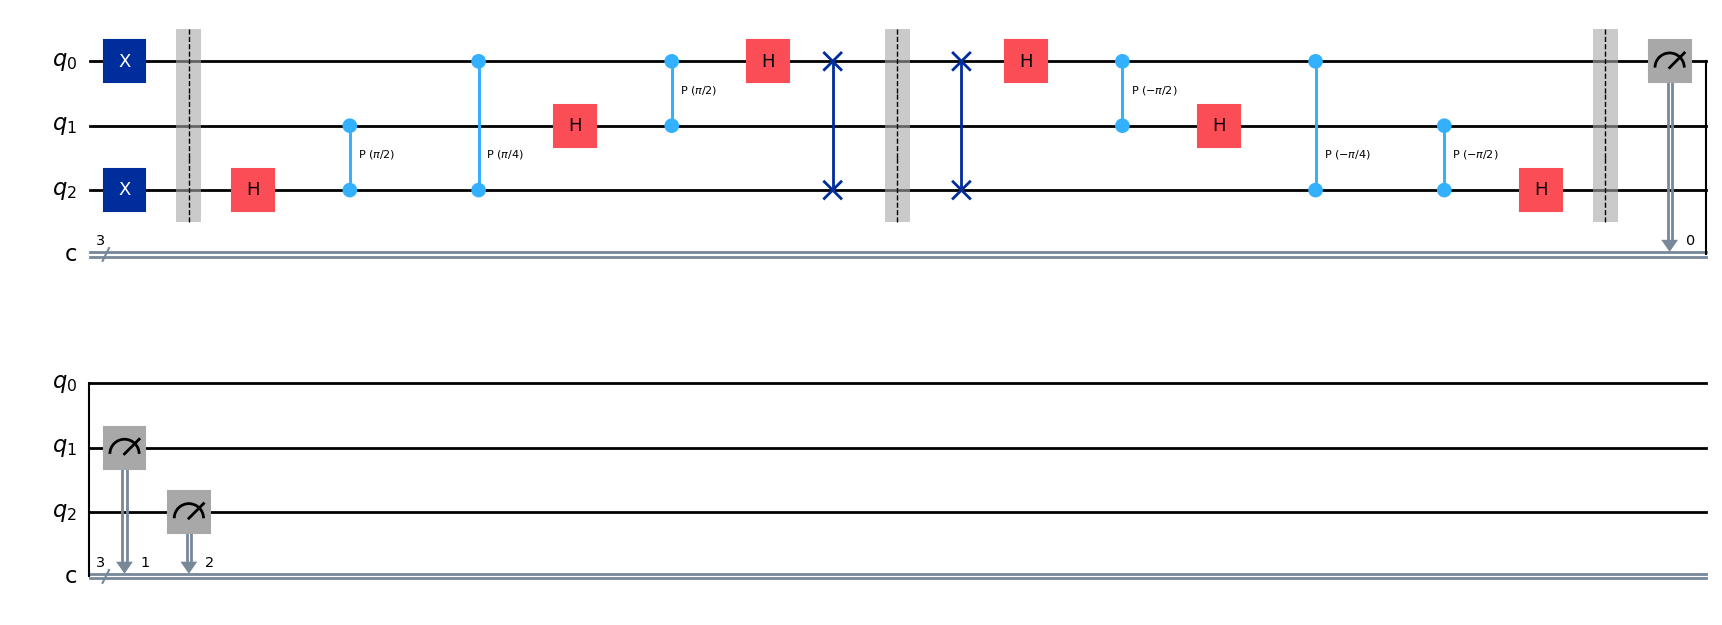


Measurement Output: {'101': 1024}


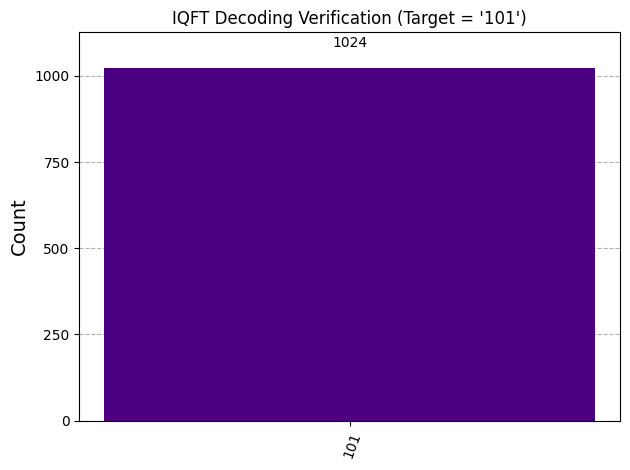

In [4]:
# 1. Initialize a 3-qubit circuit
n_qubits = 3
qc = QuantumCircuit(n_qubits, n_qubits)

# Set the state to 5 (Binary: 101)
qc.x(0)
qc.x(2)
qc.barrier()

# 2. Apply Forward QFT
qc.compose(build_qft(n_qubits), inplace=True)
qc.barrier()

# 3. Apply Inverse QFT
qc.compose(build_iqft(n_qubits), inplace=True)
qc.barrier()

# 4. Measure
qc.measure(range(n_qubits), range(n_qubits))

print("Full QFT -> IQFT Circuit:")
display(qc.draw('mpl'))

# 5. Execute using the V2 Sampler
sampler = StatevectorSampler()
job = sampler.run([qc], shots=1024)
pub_result = job.result()[0]
counts = pub_result.data.c.get_counts()

print(f"\nMeasurement Output: {counts}")

# Verify the result is exactly 101
display(plot_histogram(counts, title="IQFT Decoding Verification (Target = '101')", color='indigo'))

## Final Analysis: The Power of the QFT and IQFT

**What did we just observe?**
In these two notebooks, we successfully built and tested the core "translation engine" of advanced quantum computing:
1. **The Forward QFT (Encoding):** When we inputted the classical number `5` (`101`), the QFT mapped the binary digits into precise rotational angles on the Bloch sphere's equator. The state was transformed from the *computational basis* (where qubits are exactly 0 or 1) into the *phase basis* (where information lives in the angles of superposition). 
2. **The Inverse QFT (Decoding):** Because quantum mechanics is entirely reversible (unitary), we applied the exact opposite operations to "catch" those spinning clock hands. The IQFT seamlessly unwound the phase interference, collapsing the complex superposition back into the rigid classical state of `101` with 100% certainty.

**Why does this matter for our roadmap?**
The Quantum Fourier Transform rarely solves a problem on its own. Instead, it is the most critical **subroutine** for the heavy-lifting algorithms that give quantum computers their theoretical supremacy. 

By proving that we can reliably manipulate and decode phase rotations, we have just unlocked the exact architecture required for the final sprint of our roadmap:
* **Project 8 (Quantum Phase Estimation):** We will use the IQFT to read the hidden phases (eigenvalues) of unknown quantum operators.
* **Project 9 (Shor's Algorithm):** We will rely heavily on the QFT to find the mathematical period of a function, which is the exact mechanism used to crack RSA cryptography.